In [1]:
# check installed version
# from pycaret.classification import *
import pandas as pd
import numpy as np
import pycaret
import duckdb
import pickle
from datetime import datetime
import math

def esql(query):
    return(duckdb.sql(query).df())

pycaret.__version__
# pandas 2.1.0 pycaret 3.3.1 duckdb 0.10.2

'3.3.2'

In [2]:
tmp1 = pd.read_csv("/Users/erickim/Documents/ML_Training/d3_classification/tmp1.csv")
# dates를 SQL/시계열 처리에 안전한 날짜 타입으로 변환
tmp1['dates'] = pd.to_datetime(tmp1['dates'], errors='coerce').dt.date
tmp1.head()

,open,high,low,close,volume,adjusted,symbol,dates
0,53.889999,56.919998,53.889999,56.299999,2955600.0,53.076340,AAL,2007-01-03
1,56.299999,59.150002,53.650002,58.840000,2614500.0,55.470909,AAL,2007-01-04
2,58.830002,59.150002,57.900002,58.290001,1656300.0,54.952396,AAL,2007-01-05
3,57.299999,60.480000,57.040001,57.930000,2163200.0,54.613007,AAL,2007-01-08
4,59.439999,60.200001,57.560001,57.900002,2098600.0,54.584732,AAL,2007-01-09


In [3]:
print(tmp1.describe())
print("\n\n",tmp1.isna().sum())
print("\n\n",tmp1.dtypes)


               open          high           low         close        volume  \
count  2.204441e+06  2.204441e+06  2.204441e+06  2.204441e+06  2.204441e+06   
mean   6.050776e+01  6.138401e+01  5.960745e+01  6.050896e+01  4.925708e+06   
std    1.118063e+02  1.132096e+02  1.103716e+02  1.118090e+02  3.819374e+07   
min    5.000000e-02  5.666700e-02  4.666700e-02  5.000000e-02  1.000000e+00   
25%    1.687000e+01  1.716000e+01  1.656000e+01  1.686766e+01  2.202000e+05   
50%    3.300000e+01  3.350000e+01  3.248000e+01  3.300000e+01  6.479000e+05   
75%    6.609000e+01  6.705000e+01  6.513000e+01  6.610000e+01  2.051000e+06   
max    4.289000e+03  4.308000e+03  4.267240e+03  4.292000e+03  3.692928e+09   

           adjusted  
count  2.204441e+06  
mean   5.698542e+01  
std    1.109266e+02  
min    5.000000e-02  
25%    1.427200e+01  
50%    2.906048e+01  
75%    6.118468e+01  
max    4.292000e+03  


 open        0
high        0
low         0
close       0
volume      0
adjusted    0
sym

In [4]:
esql("select min(dates),max(dates) from tmp1")

,min(dates),max(dates)
0,2007-01-03,2024-10-10


In [5]:
print(esql("select symbol, min(dates), max(dates), count(*) from tmp1 group by symbol order by symbol"))


    symbol min(dates) max(dates)  count_star()
0      AAL 2007-01-03 2024-10-10          4474
1     AAON 2007-01-03 2024-10-10          4474
2     AAPL 2007-01-03 2024-10-10          4474
3     ABCB 2007-01-03 2024-10-10          4474
4     ACAD 2007-01-03 2024-10-10          4473
..     ...        ...        ...           ...
591   ZION 2007-01-03 2024-10-10          4474
592  ZIONO 2013-02-04 2024-10-10          2942
593  ZIONP 2007-01-05 2024-10-10          4158
594     ZM 2019-04-18 2024-10-10          1380
595     ZS 2018-03-16 2024-10-10          1654

[596 rows x 4 columns]


In [6]:
query="""select symbol, min(dates) min_date, max(dates) max_date, count(*) cnt from tmp1 
group by symbol having max(dates)>'2021-12-31' order by max_date"""
esql(query)

,symbol,min_date,max_date,cnt
0,LBTYB,2007-01-03,2024-10-07,1915
1,BIDU,2007-01-03,2024-10-10,4474
2,EXLS,2007-01-03,2024-10-10,4474
3,BPOP,2007-01-03,2024-10-10,4474
4,GO,2019-06-20,2024-10-10,1337
...,...,...,...,...
591,ILMN,2007-01-03,2024-10-10,4474
592,INDV,2014-12-29,2024-10-10,1807
593,IOSP,2007-01-03,2024-10-10,4474
594,ROKU,2017-09-28,2024-10-10,1770


In [7]:
# tmp1 기준으로 unique dates -> date_master(seq: 1부터) 생성
# 그리고 tmp1 + date_master 조인으로 tmp2 생성

date_master = (
    tmp1[['dates']]
    .dropna()
    .drop_duplicates()
    .sort_values('dates')
    .reset_index(drop=True)
)
date_master['seq'] = np.arange(1, len(date_master) + 1)

# dates로 결합
# many-to-one 관계 검증: tmp1의 여러 행이 date_master의 1개 날짜와 매칭
tmp2 = tmp1.merge(date_master, on='dates', how='left', validate='many_to_one')

# seq를 앞쪽으로 배치
tmp2 = tmp2[['seq'] + [c for c in tmp2.columns if c != 'seq']]

print("date_master shape:", date_master.shape)
print("tmp2 shape      :", tmp2.shape)
print("\n[date_master head]")
print(date_master.head())
print("\n[tmp2 head]")
print(tmp2.head())

date_master shape: (4474, 2)
tmp2 shape      : (2204441, 9)

[date_master head]
        dates  seq
0  2007-01-03    1
1  2007-01-04    2
2  2007-01-05    3
3  2007-01-08    4
4  2007-01-09    5

[tmp2 head]
   seq       open       high        low      close     volume   adjusted  \
0    1  53.889999  56.919998  53.889999  56.299999  2955600.0  53.076340   
1    2  56.299999  59.150002  53.650002  58.840000  2614500.0  55.470909   
2    3  58.830002  59.150002  57.900002  58.290001  1656300.0  54.952396   
3    4  57.299999  60.480000  57.040001  57.930000  2163200.0  54.613007   
4    5  59.439999  60.200001  57.560001  57.900002  2098600.0  54.584732   

  symbol       dates  
0    AAL  2007-01-03  
1    AAL  2007-01-04  
2    AAL  2007-01-05  
3    AAL  2007-01-08  
4    AAL  2007-01-09  


In [8]:
esql("select min(seq),max(seq) from tmp2")

,min(seq),max(seq)
0,1,4474


In [18]:
query="""select symbol, 
max(case when seq=4411 then close else null end) close_train,
avg(case when seq between 4412 and 4432 then close else null end) avg_train, 
max(case when seq between 4412 and 4432 then close else null end) max_train, 

max(case when seq=4432 then close else null end)close_test,
avg(case when seq between 4433 and 4453 then close else null end) avg_test, 
max(case when seq between 4433 and 4453 then close else null end) max_test, 

max(case when seq=4453 then close else null end) close_deploy,
avg(case when seq between 4454 and 4474 then close else null end)  avg_deploy,
max(case when seq between 4454 and 4474 then close else null end) max_deploy,

(avg(case when seq between 4412 and 4432 then close else null end) + max(case when seq between 4412 and 4432 then close else null end))/2/
max(case when seq=4411 then close else null end) train_target_ratio,

(avg(case when seq between 4433 and 4453 then close else null end) + max(case when seq between 4433 and 4453 then close else null end))/2 /
max(case when seq=4432 then close else null end) test_target_ratio,

(avg(case when seq between 4454 and 4474 then close else null end) + max(case when seq between 4454 and 4474 then close else null end))/2 /
max(case when seq=4453 then close else null end) deploy_target_ratio,
from tmp2 
group by symbol order by deploy_target_ratio desc"""
tmp3=esql(query)

In [19]:
query="""select a.*, 
case when train_target_ratio>1.05 then 1 else 0 end as train_class,
case when test_target_ratio>1.05 then 1 else 0 end as test_class, 
case when deploy_target_ratio>1.05 then 1 else 0 end as deploy_class 
from tmp3 a"""

tmp4=esql(query)
print(tmp4.head())
print(tmp4.tail())

  symbol  close_train   avg_train   max_train  close_test    avg_test  \
0   FUTU    68.570000   60.931667   67.680000   58.880001   60.860952   
1   BILI    16.709999   15.087619   16.100000   13.490000   14.354286   
2     JD    28.150000   26.118095   27.200001   26.070000   26.782857   
3    PDD   142.419998  132.183810  142.470001  142.470001  116.218095   
4     WB     8.500000    7.786667    8.240000    8.190000    7.619048   

     max_test  close_deploy  avg_deploy  max_deploy  train_target_ratio  \
0   63.560001     59.610001   87.430952  128.929993            0.937813   
1   15.630000     15.630000   20.603333   29.660000            0.933202   
2   29.540001     26.559999   36.240953   47.080002            0.947035   
3  151.110001     95.279999  123.899048  154.270004            0.964239   
4    8.350000      7.230000    9.168571   11.710000            0.942745   

   test_target_ratio  deploy_target_ratio  train_class  test_class  \
0           1.056564             1.81480

In [20]:
print(esql("select train_class, count(*) from tmp4 group by train_class order by train_class"))
print("\n")
print(esql("select test_class, count(*) from tmp4 group by test_class order by test_class"))
print("\n")
print(esql("select deploy_class, count(*) from tmp4 group by deploy_class order by deploy_class"))

   train_class  count_star()
0            0           390
1            1           206


   test_class  count_star()
0           0           249
1           1           347


   deploy_class  count_star()
0             0           279
1             1           317


In [14]:
query="""
select b.symbol, train_class,b.close_train, a.avg_close_30,avg_close_60,avg_close_90,avg_close_120,
avg_close_150,avg_close_180,avg_close_210,avg_close_30_60,avg_close_30_120
from (
    select symbol, 
    avg(case when seq between 4411-30 and 4411 then close else null end) avg_close_30 ,
    avg(case when seq between 4411-60 and 4411 then close else null end) avg_close_60 ,
    avg(case when seq between 4411-90 and 4411 then close else null end) avg_close_90 ,
    avg(case when seq between 4411-120 and 4411 then close else null end) avg_close_120 ,
    avg(case when seq between 4411-150 and 4411 then close else null end) avg_close_150 ,
    avg(case when seq between 4411-180 and 4411 then close else null end) avg_close_180 ,
    avg(case when seq between 4411-210 and 4411 then close else null end) avg_close_210 ,
    avg(case when seq between 4411-30 and 4411 then close else null end) / 
    avg(case when seq between 4411-60 and 4411 then close else null end)  avg_close_30_60,
    avg(case when seq between 4411-30 and 4411 then close else null end) / 
    avg(case when seq between 4411-120 and 4411 then close else null end)  avg_close_30_120,
    from tmp2 group by symbol 
) a, tmp4 b 
where a.symbol=b.symbol order by b.symbol
"""  
tmp5=esql(query)
tmp5

,symbol,train_class,close_train,avg_close_30,avg_close_60,avg_close_90,avg_close_120,avg_close_150,avg_close_180,avg_close_210,avg_close_30_60,avg_close_30_120
0,AAL,0,10.680000,11.259032,12.689836,13.228681,13.615124,13.667351,13.373812,13.269763,0.887248,0.826950
1,AAON,0,90.029999,79.960001,81.060328,82.410989,81.243554,79.154239,75.882210,73.328531,0.986426,0.984201
2,AAPL,0,230.539993,210.494516,195.147377,187.421538,187.243140,187.935364,187.050221,185.437583,1.078644,1.124177
3,ABCB,1,54.529999,48.890968,48.649672,48.020659,48.146446,48.621788,47.295470,45.991801,1.004960,1.015464
4,ACAD,0,17.770000,15.650968,15.907049,17.029231,19.212727,20.967682,21.242597,21.546588,0.983901,0.814615
...,...,...,...,...,...,...,...,...,...,...,...,...
591,ZION,1,47.230000,42.482903,42.571639,42.183736,41.825537,41.915828,40.540829,39.705877,0.997916,1.015717
592,ZIONO,0,25.450001,25.433871,25.530328,25.493956,25.627686,25.611126,25.546961,25.483175,0.996222,0.992437
593,ZIONP,1,21.270000,21.299152,20.914574,20.631459,20.536106,20.382123,20.148046,20.041245,1.018388,1.037156
594,ZM,0,57.580002,59.244839,60.615574,62.243626,63.110909,64.564437,64.354420,64.757725,0.977386,0.938742


In [15]:
tmp5.columns

Index(['symbol', 'train_class', 'close_train', 'avg_close_30', 'avg_close_60',
       'avg_close_90', 'avg_close_120', 'avg_close_150', 'avg_close_180',
       'avg_close_210', 'avg_close_30_60', 'avg_close_30_120'],
      dtype='str')

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython import get_ipython

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay, f1_score)
from sklearn.ensemble import (
    RandomForestClassifier,
    BaggingClassifier,
    GradientBoostingClassifier,
    StackingClassifier,
    VotingClassifier,
)

In [17]:
tmp6=tmp5.copy()

In [18]:
X_train = tmp6.drop(['train_class','symbol'], axis=1)
y_train = tmp6['train_class']

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)


In [20]:
dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(X_train_sc, y_train)

y_pred_dt = dt.predict(X_train_sc)
print(f"Accuracy : {accuracy_score(y_train, y_pred_dt):.4f}")
print(classification_report(y_train, y_pred_dt,target_names=['0', '1']))

Accuracy : 0.7181
              precision    recall  f1-score   support

           0       0.73      0.90      0.81       390
           1       0.66      0.37      0.48       206

    accuracy                           0.72       596
   macro avg       0.70      0.64      0.64       596
weighted avg       0.71      0.72      0.69       596



In [21]:
fi_dt = pd.Series(dt.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print("Feature Importance:")
print(fi_dt)

Feature Importance:
avg_close_30_60     0.476275
avg_close_30_120    0.187849
avg_close_30        0.151396
avg_close_150       0.075267
avg_close_90        0.071327
avg_close_120       0.037885
close_train         0.000000
avg_close_60        0.000000
avg_close_180       0.000000
avg_close_210       0.000000
dtype: float64


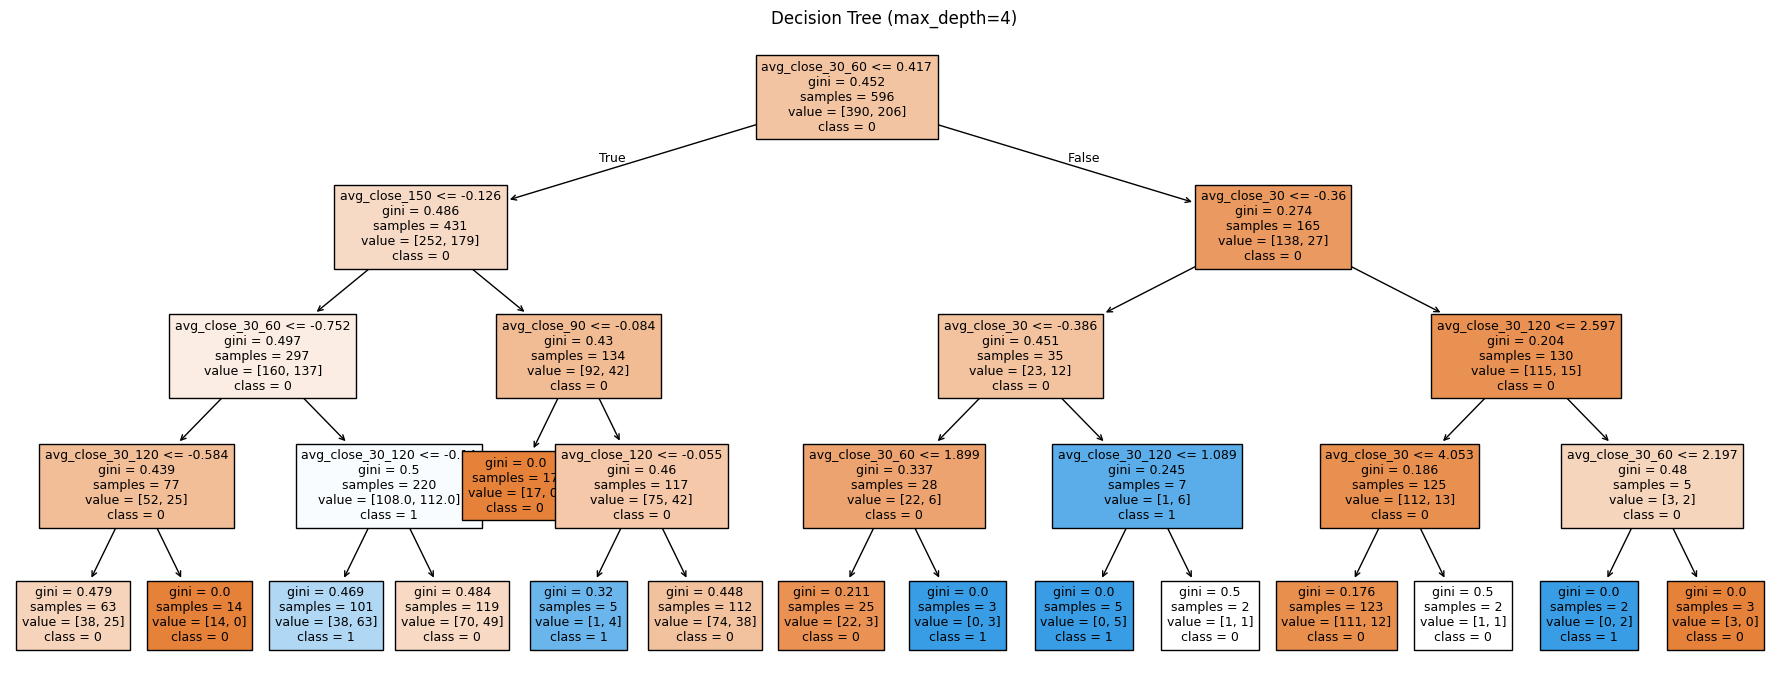

In [22]:
fig, ax = plt.subplots(figsize=(18, 7))
plot_tree(
    dt,
    feature_names=X_train.columns.tolist(),
    class_names=['0', '1'],
    filled=True,
    fontsize=9,
    ax=ax,
)
ax.set_title("Decision Tree (max_depth=4)")
fig.tight_layout()
plt.show()

In [23]:
train_result=pd.concat([tmp6, pd.DataFrame(y_pred_dt, columns=['y_pred_dt'])], axis=1)
train_result.head()

,symbol,train_class,close_train,avg_close_30,avg_close_60,avg_close_90,avg_close_120,avg_close_150,avg_close_180,avg_close_210,avg_close_30_60,avg_close_30_120,y_pred_dt
0,AAL,0,10.680000,11.259032,12.689836,13.228681,13.615124,13.667351,13.373812,13.269763,0.887248,0.826950,0
1,AAON,0,90.029999,79.960001,81.060328,82.410989,81.243554,79.154239,75.882210,73.328531,0.986426,0.984201,0
2,AAPL,0,230.539993,210.494516,195.147377,187.421538,187.243140,187.935364,187.050221,185.437583,1.078644,1.124177,0
3,ABCB,1,54.529999,48.890968,48.649672,48.020659,48.146446,48.621788,47.295470,45.991801,1.004960,1.015464,0
4,ACAD,0,17.770000,15.650968,15.907049,17.029231,19.212727,20.967682,21.242597,21.546588,0.983901,0.814615,1


In [24]:
esql("select y_pred_dt, train_class, count(*) cnt from train_result group by y_pred_dt, train_class order by y_pred_dt, train_class")

,y_pred_dt,train_class,cnt
0,0,0,351
1,0,1,129
2,1,0,39
3,1,1,77


In [25]:
print("precision : ", 87/(53+87))
print("recall    : ", 119/(119+87))
print("baseline  : ", (119+87)/(337+119+53+87))

precision :  0.6214285714285714
recall    :  0.5776699029126213
baseline  :  0.34563758389261745


In [26]:
query="""
select b.symbol, test_class,b.close_test close_train, a.avg_close_30,avg_close_60,avg_close_90,avg_close_120,
avg_close_150,avg_close_180,avg_close_210,avg_close_30_60,avg_close_30_120
from (
    select symbol, 
    avg(case when seq between 4432-30 and 4432 then close else null end) avg_close_30 ,
    avg(case when seq between 4432-60 and 4432 then close else null end) avg_close_60 ,
    avg(case when seq between 4432-90 and 4432 then close else null end) avg_close_90 ,
    avg(case when seq between 4432-120 and 4432 then close else null end) avg_close_120 ,
    avg(case when seq between 4432-150 and 4432 then close else null end) avg_close_150 ,
    avg(case when seq between 4432-180 and 4432 then close else null end) avg_close_180 ,
    avg(case when seq between 4432-210 and 4432 then close else null end) avg_close_210 ,
    avg(case when seq between 4432-30 and 4432 then close else null end)  /
    avg(case when seq between 4432-60 and 4432 then close else null end) avg_close_30_60,
    avg(case when seq between 4432-30 and 4432 then close else null end)  /
    avg(case when seq between 4432-120 and 4432 then close else null end) avg_close_30_120,
    
    from tmp2 group by symbol 
) a, tmp4 b 
where a.symbol=b.symbol order by b.symbol
"""  
tmp7=esql(query)
tmp7

,symbol,test_class,close_train,avg_close_30,avg_close_60,avg_close_90,avg_close_120,avg_close_150,avg_close_180,avg_close_210,avg_close_30_60,avg_close_30_120
0,AAL,1,9.610000,10.498387,11.354754,12.221978,12.865207,13.162119,13.211602,12.996919,0.924581,0.816029
1,AAON,1,87.389999,87.153871,82.008853,83.272088,83.413967,81.534636,79.328398,76.202085,1.062737,1.044835
2,AAPL,0,217.529999,221.400323,210.757213,198.489121,192.661488,191.663775,191.771436,189.925024,1.050499,1.149168
3,ABCB,1,55.660000,56.077097,52.236066,50.684505,49.674628,49.729470,49.494254,48.015782,1.073532,1.128888
4,ACAD,1,15.290000,17.493226,16.367541,16.553736,17.758099,19.626954,20.682762,20.992559,1.068775,0.985084
...,...,...,...,...,...,...,...,...,...,...,...,...
591,ZION,1,45.490002,47.531935,44.948361,43.993407,43.146694,42.886093,42.429061,41.133934,1.057479,1.101636
592,ZIONO,0,25.590000,25.524839,25.555738,25.524176,25.520248,25.620265,25.606298,25.526967,0.998791,1.000180
593,ZIONP,0,21.945499,21.897719,21.662330,21.100517,20.906960,20.695041,20.557276,20.287447,1.010866,1.047389
594,ZM,1,55.320000,58.159194,59.560410,60.278077,61.816157,62.757848,63.954061,63.722157,0.976474,0.940841


In [28]:
X_test = tmp7.drop(['test_class','symbol'], axis=1)
y_test = tmp7['test_class']

X_test_sc = scaler.transform(X_test)

y_pred_dt = dt.predict(X_test_sc)
print(f"Accuracy : {accuracy_score(y_test, y_pred_dt):.4f}")
print(classification_report(y_test, y_pred_dt,target_names=['0', '1']))

Accuracy : 0.4681
              precision    recall  f1-score   support

           0       0.43      0.85      0.57       249
           1       0.64      0.20      0.30       347

    accuracy                           0.47       596
   macro avg       0.54      0.52      0.44       596
weighted avg       0.55      0.47      0.41       596



In [29]:
test_result=pd.concat([tmp7, pd.DataFrame(y_pred_dt, columns=['y_pred_dt'])], axis=1)
test_result.head()

,symbol,test_class,close_train,avg_close_30,avg_close_60,avg_close_90,avg_close_120,avg_close_150,avg_close_180,avg_close_210,avg_close_30_60,avg_close_30_120,y_pred_dt
0,AAL,1,9.610000,10.498387,11.354754,12.221978,12.865207,13.162119,13.211602,12.996919,0.924581,0.816029,0
1,AAON,1,87.389999,87.153871,82.008853,83.272088,83.413967,81.534636,79.328398,76.202085,1.062737,1.044835,0
2,AAPL,0,217.529999,221.400323,210.757213,198.489121,192.661488,191.663775,191.771436,189.925024,1.050499,1.149168,0
3,ABCB,1,55.660000,56.077097,52.236066,50.684505,49.674628,49.729470,49.494254,48.015782,1.073532,1.128888,0
4,ACAD,1,15.290000,17.493226,16.367541,16.553736,17.758099,19.626954,20.682762,20.992559,1.068775,0.985084,0


In [30]:
esql("select y_pred_dt, test_class, count(*) cnt from test_result group by y_pred_dt, test_class order by y_pred_dt, test_class")

,y_pred_dt,test_class,cnt
0,0,0,211
1,0,1,279
2,1,0,38
3,1,1,68


In [33]:
rf = RandomForestClassifier(n_estimators=500, max_depth=5, class_weight='balanced',random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
print(f"Accuracy : {accuracy_score(y_test, y_pred_rf):.4f}")
print(classification_report(y_test, y_pred_rf,target_names=['0', '1']))

Accuracy : 0.4413
              precision    recall  f1-score   support

           0       0.39      0.59      0.47       249
           1       0.53      0.33      0.41       347

    accuracy                           0.44       596
   macro avg       0.46      0.46      0.44       596
weighted avg       0.47      0.44      0.43       596



In [34]:
fi_rf = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print("Feature Importance:")
print(fi_rf)

Feature Importance:
avg_close_30_60     0.223713
avg_close_30_120    0.163902
avg_close_30        0.090753
close_train         0.086572
avg_close_60        0.077626
avg_close_90        0.073629
avg_close_150       0.072117
avg_close_210       0.070678
avg_close_180       0.070574
avg_close_120       0.070435
dtype: float64


In [35]:
test_result=pd.concat([tmp7, pd.DataFrame(y_pred_rf, columns=['y_pred_dt'])], axis=1)
test_result.head()

,symbol,test_class,close_train,avg_close_30,avg_close_60,avg_close_90,avg_close_120,avg_close_150,avg_close_180,avg_close_210,avg_close_30_60,avg_close_30_120,y_pred_dt
0,AAL,1,9.610000,10.498387,11.354754,12.221978,12.865207,13.162119,13.211602,12.996919,0.924581,0.816029,0
1,AAON,1,87.389999,87.153871,82.008853,83.272088,83.413967,81.534636,79.328398,76.202085,1.062737,1.044835,0
2,AAPL,0,217.529999,221.400323,210.757213,198.489121,192.661488,191.663775,191.771436,189.925024,1.050499,1.149168,0
3,ABCB,1,55.660000,56.077097,52.236066,50.684505,49.674628,49.729470,49.494254,48.015782,1.073532,1.128888,0
4,ACAD,1,15.290000,17.493226,16.367541,16.553736,17.758099,19.626954,20.682762,20.992559,1.068775,0.985084,0


In [36]:
esql("select y_pred_dt, test_class, count(*) cnt from test_result group by y_pred_dt, test_class order by y_pred_dt, test_class")

,y_pred_dt,test_class,cnt
0,0,0,147
1,0,1,231
2,1,0,102
3,1,1,116


In [37]:
test_result=pd.concat([tmp7, pd.DataFrame(y_pred_dt, columns=['y_pred_dt']), pd.DataFrame(y_pred_rf, columns=['y_pred_rf'])], axis=1)
test_result.head()

,symbol,test_class,close_train,avg_close_30,avg_close_60,avg_close_90,avg_close_120,avg_close_150,avg_close_180,avg_close_210,avg_close_30_60,avg_close_30_120,y_pred_dt,y_pred_rf
0,AAL,1,9.610000,10.498387,11.354754,12.221978,12.865207,13.162119,13.211602,12.996919,0.924581,0.816029,0,0
1,AAON,1,87.389999,87.153871,82.008853,83.272088,83.413967,81.534636,79.328398,76.202085,1.062737,1.044835,0,0
2,AAPL,0,217.529999,221.400323,210.757213,198.489121,192.661488,191.663775,191.771436,189.925024,1.050499,1.149168,0,0
3,ABCB,1,55.660000,56.077097,52.236066,50.684505,49.674628,49.729470,49.494254,48.015782,1.073532,1.128888,0,0
4,ACAD,1,15.290000,17.493226,16.367541,16.553736,17.758099,19.626954,20.682762,20.992559,1.068775,0.985084,0,0


In [38]:
query="""select case when y_pred_dt*0.7+y_pred_rf*0.3>0.5 then 1 else 0 end  y_pred, test_class, count(*) cnt 
from test_result 
group by y_pred, test_class order by y_pred, test_class"""

esql(query)

,y_pred,test_class,cnt
0,0,0,211
1,0,1,279
2,1,0,38
3,1,1,68


In [39]:
query="""
select a.symbol, b.dates, b.high, a.dates, a.close from tmp2 a, tmp2 b 
where a.symbol=b.symbol and a.seq=b.seq-1
"""
esql(query)

,symbol,dates,high,dates_1,close
0,CMCSA,2022-08-03,38.639999,2022-08-02,37.680000
1,CMCSA,2022-08-04,39.220001,2022-08-03,38.480000
2,CMCSA,2022-08-05,38.419998,2022-08-04,38.930000
3,CMCSA,2022-08-08,39.380001,2022-08-05,38.270000
4,CMCSA,2022-08-09,38.740002,2022-08-08,38.590000
...,...,...,...,...,...
2199600,VRTX,2023-07-17,359.339996,2023-07-14,352.739990
2199601,VRTX,2023-07-18,359.329987,2023-07-17,357.980011
2199602,VRTX,2023-07-19,365.529999,2023-07-18,358.980011
2199603,VRTX,2023-07-20,365.559998,2023-07-19,358.570007


In [40]:
query="""
select a.symbol, sum(case when b.high / a.close > 1.03 then 1 else 0 end) as peak_cnt
from tmp2 a, tmp2 b 
where a.symbol=b.symbol and a.seq=b.seq-1 and a.seq < 4411 and a.seq > 4411-400
group by a.symbol order by a.symbol
"""
train_peak=esql(query)
train_peak.head()

,symbol,peak_cnt
0,AAL,63.0
1,AAON,54.0
2,AAPL,20.0
3,ABCB,66.0
4,ACAD,69.0


In [41]:
query="""
select a.symbol, sum(case when b.high / a.close > 1.03 then 1 else 0 end) as peak_cnt
from tmp2 a, tmp2 b 
where a.symbol=b.symbol and a.seq=b.seq-1 and a.seq < 4432 and a.seq > 4432-400
group by a.symbol order by a.symbol
"""
test_peak=esql(query)
test_peak.head()

,symbol,peak_cnt
0,AAL,60.0
1,AAON,57.0
2,AAPL,18.0
3,ABCB,69.0
4,ACAD,68.0


In [42]:
query="""
select a.symbol, sum(case when b.high / a.close > 1.03 then 1 else 0 end) as peak_cnt
from tmp2 a, tmp2 b 
where a.symbol=b.symbol and a.seq=b.seq-1 and a.seq < 4453 and a.seq > 4453-400
group by a.symbol order by a.symbol
"""
deploy_peak=esql(query)
deploy_peak.head()

,symbol,peak_cnt
0,AAL,62.0
1,AAON,56.0
2,AAPL,15.0
3,ABCB,67.0
4,ACAD,66.0


In [43]:
print("train stat : ", train_peak.describe())
print("test stat  : ", test_peak.describe())
print("deploy stat: ", deploy_peak.describe())


train stat :           peak_cnt
count  596.000000
mean    57.840604
std     42.381339
min      2.000000
25%     25.000000
50%     48.000000
75%     81.000000
max    255.000000
test stat  :           peak_cnt
count  596.000000
mean    57.748322
std     41.976269
min      2.000000
25%     25.000000
50%     49.000000
75%     80.000000
max    255.000000
deploy stat:           peak_cnt
count  596.000000
mean    56.703020
std     41.433118
min      2.000000
25%     24.750000
50%     48.000000
75%     79.000000
max    248.000000


In [44]:
print(tmp6.dtypes)
print(train_peak.dtypes)

symbol                  str
train_class           int32
close_train         float64
avg_close_30        float64
avg_close_60        float64
avg_close_90        float64
avg_close_120       float64
avg_close_150       float64
avg_close_180       float64
avg_close_210       float64
avg_close_30_60     float64
avg_close_30_120    float64
dtype: object
symbol          str
peak_cnt    float64
dtype: object


In [45]:
X_train = pd.merge(tmp6, train_peak, on='symbol', how='left')
X_train = X_train.drop(['train_class','symbol'], axis=1)
y_train = tmp6['train_class']

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)

In [46]:
dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_train)
print(f"Accuracy : {accuracy_score(y_train, y_pred_dt):.4f}")
print(classification_report(y_train, y_pred_dt,target_names=['0', '1']))

fi_dt = pd.Series(dt.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print("Feature Importance:")
print(fi_dt)

Accuracy : 0.7181
              precision    recall  f1-score   support

           0       0.75      0.85      0.80       390
           1       0.62      0.48      0.54       206

    accuracy                           0.72       596
   macro avg       0.69      0.66      0.67       596
weighted avg       0.71      0.72      0.71       596

Feature Importance:
avg_close_30_60     0.393658
peak_cnt            0.230748
avg_close_150       0.167230
avg_close_30        0.130738
avg_close_90        0.077626
close_train         0.000000
avg_close_60        0.000000
avg_close_120       0.000000
avg_close_180       0.000000
avg_close_210       0.000000
avg_close_30_120    0.000000
dtype: float64
